# MITGCM Transect Spectral Analysis 

**Purpose**: Code for preforming the transect spectral nalysis. I will compute the FVE along a transect off the  coast of southern california. 

**Luke Colosi | lcolosi@ucsd.edu**

Force matplotlib plots to display directly within the output cell of the notebook

In [1]:
%matplotlib inline

Import python libraries

In [2]:
import sys
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt 
from netCDF4 import Dataset, num2date
from datetime import datetime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import cmocean.cm as cmo
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
from scipy.stats import chi2
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker

# Set path to access python functions
ROOT = '/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/'
sys.path.append(ROOT + 'AirSeaCoupling/tools/')

#--- Other Functions ---# 
import cartopy_figs as cart
from autocorr import compute_autocorr_optimize, compute_decor_scale_optimize, segment_time_series, bootstrap_decorrelation_scale, windowed_decorrelation_scale, compute_autocorr_optimize
from spectra import spectrum1D_frequency, spectral_slope
from lsf import unweighted_lsf, detrend, compute_amp_phase
from structure_functions import compute_structure_function
from var_analysis import variance_scale_analysis_1D
from ocean_analysis import compute_mld
from plotScaleAnalysis import month_fmt, add_freq_marker

Set data analysis parameters

In [3]:
# Set processing parameters
option_plot          = 0          # Specifies if supplementary plots are plotted
option_var           = 'density'  # Specifies which variable will analyzed. Options include: temp, sal, density, u_along, v_cross

# Set time and space parameters
dt           = 1*(60)*(60)                   # Specifies the time interval for model run. Units: seconds
estimator    = 'biased'                      # Specifies the approach for estimating the autocorrelation function    
lat_bnds     = [33, 35]                      # Specifies the latitude bounds for the region to analyze
lon_bnds     = [-123 % 360, -120 % 360]      # Specifies the longitude bounds for the region to analyze

# Set path to project directory
PATH = ROOT + 'AirSeaCoupling/data/mitgcm/SWOT_MARA_RUN4_LY/spatial/transect/'
PATH_figs =  ROOT + 'AirSeaCoupling/figs/OSM26/'
PATH_bathy  = ROOT + 'AirSeaCoupling/data/bathymetry/'

# Set plotting parameters 
fontsize = 15

# Set font and fontsize
os.environ["PATH"] = "/usr/local/texlive/2022/bin/universal-darwin:" + os.environ["PATH"]
plt.rcParams.update({
    "font.size": fontsize,         # Fontsize
    "text.usetex": True,           # Use LaTeX for all text
    "font.family": "serif",        # Optional: match LaTeX font
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: load extra LaTeX packages
}) 

Load mitgcm data netcdf files 

In [4]:
#--- MITgcm Data ---# 
if (option_var == 'temp') | (option_var == 'sal') | (option_var == 'density'):
    filename = PATH + "mitgcm_intermediate_data_TSD_hrly_transect_profiles.nc"
elif (option_var == 'u_along') | (option_var == 'v_cross'):
    filename = PATH + "mitgcm_intermediate_data_vel_hrly_transect_profiles.nc"
nc = Dataset(filename, 'r')

# Extract data variables
depth = nc.variables['depth'][:]
lon   = nc.variables['LON'][:]
lat   = nc.variables['LAT'][:]
dist  = nc.variables['DIST'][:]     
time  =  num2date(nc.variables['time'][:], nc.variables['time'].units)

if option_var == 'temp':
    data = nc.variables['CTemp'][:]
elif option_var == 'sal':
    data = nc.variables['ASal'][:]
elif option_var == 'density':
    data = nc.variables['SIG'][:]
elif option_var == 'u_along': 
    data = nc.variables['u_along'][:]
elif option_var == 'v_cross': 
    data = nc.variables['v_cross'][:]

# Convert cftime.DatetimeGregorian to Python datetime objects
time_dt = np.array([datetime(d.year, d.month, d.day, d.hour, d.minute, d.second) for d in time])

# Flip the distance axis of the data array to match the orientation of the distance coordinates (increasing from left to right)
lon = lon[::-1]
lat = lat[::-1]
data = data[::-1,:,:]

Load in the ocean bottom land mask

In [5]:
# Set filename and read in netcdf file
filename = PATH + "ocean_bottom_CCS4_transect_calCOFI_line80.nc"
nc = Dataset(filename, 'r')

# Extract data variables
bottom_depth = nc.variables['bottom_depth'][:]

# Reverse order of bottom depth 
bottom_depth = bottom_depth[::-1]

Set the locations of each cce mooring

In [6]:
#--- CCE 1 ---# 
lon1 = -122.52233 
lat1 = 33.457

#--- CCE 2 ---# 
lon2 = -120.8042 
lat2 = 34.3075

#--- CCE 3 ---# 
lon3 = -120.53825701527784
lat3 = 34.44825228022894

Slice the data so that the analysis only considers the upper 200 meters and offshore distances up to 123 degrees west

In [7]:
# Find the indices for the upper 200 meters and specified lat and lon bounds
dist_mask = ((lat >= lat_bnds[0]) & (lat <= lat_bnds[1]) & (lon >= lon_bnds[0]) & (lon <= lon_bnds[1]))
idx_dist  = np.where(dist_mask)[0]
idx_depth = np.where(depth >= -215)[0]

# Extract indices for upper 200 meters and specified lat and lon bounds
depth = depth[idx_depth]
lat   = lat[idx_dist]
lon   = lon[idx_dist]
dist  = dist[idx_dist]
bottom_depth = bottom_depth[idx_dist]
data  = data[idx_dist, :, :][:, :, idx_depth]

Compute the time-mean transect

In [8]:
data_mean = np.mean(data, axis=1)
data_var = np.var(data, ddof=1, axis=1)

Plot the time-mean data along the transect 

/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_67806/2431651401.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


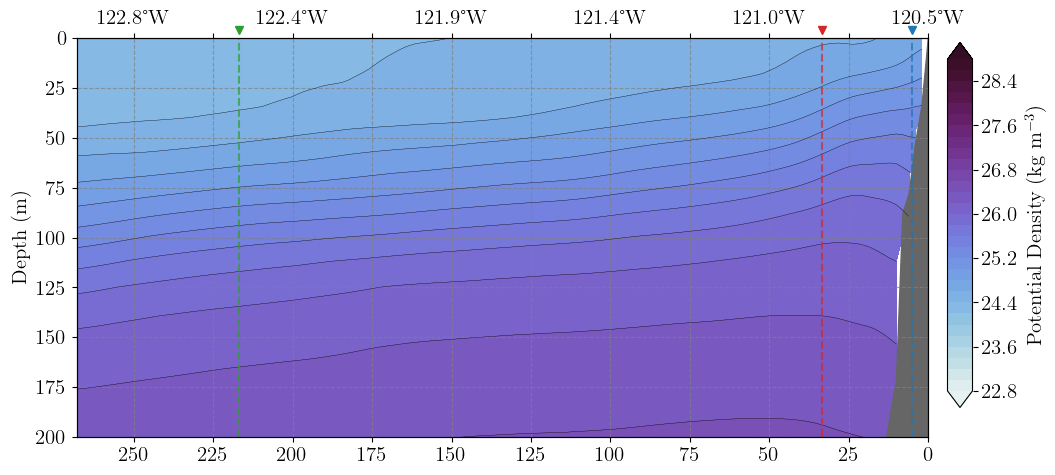

In [9]:
# Set plotting parameters
if option_var == 'temp':
    label = r'Conservative Temperature (deg C)'
    cmap = cmo.thermal
elif option_var == 'sal':
    label = r'Absolute Salinity (g/kg)'
    cmap = cmo.haline
elif option_var == 'density': 
    label = r'Potential Density (kg m$^{-3}$)'
    cmap = cmo.dense
    levels_n = np.arange(22.8,29,0.2)
    levels = np.arange(25, 26 + 0.5, 0.5)
elif option_var == 'u_along': 
    label = r'Along-transect (cross-shore) Velocity (ms$^{-1}$)'
    cmap = cmo.balance
    levels_n = np.arange(-0.15, 0.15+0.005, 0.005)
elif option_var == 'v_cross': 
    label = r'Cross-transect (alongshore) Velocity (ms$^{-1}$)'
    cmap = cmo.balance
    levels_n = np.arange(-0.15, 0.15+0.005, 0.005)

# Create figure
fig, ax = plt.subplots(1,1,figsize=(10,5))

# Plot time-mean data
cf = ax.contourf(dist,abs(depth),data_mean.T, levels=levels_n, cmap=cmap, extend='both')
ax.contour(dist,abs(depth),data_mean.T, levels=levels_n,colors='k',linewidths=0.25)
ax.contour(dist,abs(depth),data_mean.T, levels=[0],colors='k',linewidths=1)

# Plot the ocean bottom depth 
ax.fill_between(dist, abs(bottom_depth), abs(depth[-1]), color='0.4') 

# Set axis attributes
ax.set_ylabel('Depth (m)')
ax.set_ylim(0,200)
ax.set_xticks(np.arange(0,250+25,25))
ax.invert_xaxis()
ax.invert_yaxis()
ax.grid(linestyle='--',alpha=0.7,color='grey')

# Set colorbar
cax = fig.add_axes([0.96, 0.16, 0.025, 0.73])# [left, bottom, width, height]
cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both')
cbar.set_label(label)

# --- Create top axis for longitude --- #
ax_top = ax.twiny()

# Make sure limits match
ax_top.set_xlim(ax.get_xlim())

# Choose where you want longitude ticks (same positions as distance ticks)
dist_ticks = ax.get_xticks()

# Interpolate longitude at those distance values
lon_180 = ((lon + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist, lon_180)

# Create labels but only keep every other one
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set ticks and labels
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels) 

sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist[sort_idx]

# Interpolate longtiude onto distance coordinates 
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

# Add CCE1, CCE2, and CCE3 locations 
add_freq_marker(ax_top, dist1, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:green',markeredgecolor='tab:green')
add_freq_marker(ax_top, dist2, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:red',markeredgecolor='tab:red')
add_freq_marker(ax_top, dist3, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:blue',markeredgecolor='tab:blue')

# Plot vertical lines at CCE1, CCE2, and CCE3 locations
ax.axvline(dist1, color='tab:green', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist2, color='tab:red', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist3, color='tab:blue', linestyle='--', lw=1.5, alpha=0.7)

# Display 
plt.tight_layout()
plt.show()

Preform spectral analysis

In [10]:
# Set parameters
w1, w2        = [(2*np.pi)/31557600, (2)*(2*np.pi)/31557600]      # Radian Frequency for annual and semi-annual cycles. Units: rad/sec
segment_years = 1 
overlap       = 0.5

# Obtain a example segment 
segments = segment_time_series(time_dt, data[0,:,0], segment_years=segment_years, overlap=overlap)

# Set dimensions     
nseg,ntime  = np.shape(segments)[0], np.shape(segments)[2]
ndist,_,ndepth = np.shape(data)

# Set autocorrelation parameters
lag       = ntime
norm      = 0
estimator = 'biased'

# Set spectral parameters
M = 10                                                       # Specifies number of windows to divide the data into for the Welch method
p = ntime // M                                               # Specifies window length, i.e., number of data points in each segment
nfft = (p // 2 + 1) if (p % 2 == 0) else ((p - 1) // 2)      # Specifies number of positive frequency bins in the resulting power spectrum
units = 'Hz'                                                 # Specifies the units of the frequency vector 
f_cut = 1/7                                                  # Cutoff frequency for FVE calculation units: cpd

# Set autocorrelation parameters 
estimator = 'biased'                                        # Specifies the type of autocorrelation estimator ('biased' or 'unbiased')
T_days = dt*(1/60)*(1/60)*(1/24)

# Define frequency range for slope fitting 
fmin_sub = 3*10**(-2) 
fmax_sub = 8*10**(-1) 
fmin_sup = 1 
fmax_sup = 12

# Convert to seconds since start time
t0 = time_dt[0]
time_elapsed = np.array([(t - t0).total_seconds() for t in time_dt])

# Initialize arrays 
Lt              = np.zeros((ndist,ndepth))
Lt_stdm         = np.zeros((ndist,ndepth))
S_seg           = np.zeros((ndist,ndepth,nfft))
CI_seg          = np.zeros((ndist,ndepth,nfft,2))
fve_seg         = np.zeros((ndist,ndepth))
fve_seg_unc     = np.zeros((ndist,ndepth))
var_anomaly     = np.zeros((ndist,ndepth))
var_anomaly_unc = np.zeros((ndist,ndepth))

# Loop through distance offshore 
for idist in range(0,ndist):
    
    # Set progress bar
    progress = (idist + 1) / (ndist-1)
    sys.stdout.write(f"\rProgress: {progress:.1%}")
    sys.stdout.flush()

    # Loop through depth
    for idepth in range(0,ndepth):
        
        # Initialize the ith time series 
        data_ts = data[idist,:,idepth]

        # Skip depth if all values are masked
        if np.all(data_ts.mask):
            continue

        # Remove annual and semi-annual cycle 
        hfit, x_data, x_data_sigma, _ = unweighted_lsf(data_ts, time_elapsed, parameters = 2, freqs = np.array([w1,w2]), sigma = None)
        data_ts_rm = data_ts - hfit

        # Segment the time series 
        segments = segment_time_series(time_dt, data_ts_rm, segment_years=segment_years, overlap=overlap)

        # Initialize arrays
        S_seg_tmp      = np.full((nseg,nfft), np.nan)
        CI_seg_tmp     = np.zeros((nseg,nfft,2))
        var_seg_con    = np.zeros((nseg,2))
        var_seg_anom   = np.zeros((nseg,1))
        stdv_seg_anom  = np.zeros((nseg,1))
        fve_seg_tmp    = np.zeros((nseg,1))

        # Loop through segments
        for i, (tseg, dseg) in enumerate(segments):

            # Compute the elapsed time from beginning of segmented time series (units: seconds)
            t0 = tseg[0]
            time_elapsed_seg = np.array([(t - t0).total_seconds() for t in tseg])
            
            # Detrend data record 
            data_dt = detrend(dseg, time_elapsed_seg, mean = 0)

            # # Compute autocorrelation function
            # lag = len(time_elapsed_seg)
            # autocorr_tmp, _, _, _, time_lag_tmp, _ = compute_autocorr_optimize(data_dt, time_elapsed_seg, lag, estimator, 0)

            # # Compute the decorrelation scale and the number of independent samples 
            # Lt_tmp = compute_decor_scale_optimize(autocorr_tmp,time_lag_tmp,dt,'unbiased',0)
            # Lt_tmp_days = Lt_tmp * (1/60) * (1/60) * (1/24)
            
            # # Compute the number of independent samples
            # n_d = Lt_tmp_days/T_days
            # Neff = len(dseg)/n_d

            # Compute the variance of the ith segment 
            var_seg_anom[i] = np.var(dseg, ddof=1) 
            #stdv_seg_anom[i] = var_seg_anom[i]*np.sqrt(2/(Neff - 1))

            # Compute frequency power spectrum
            data_interp = np.interp(time_elapsed_seg, time_elapsed_seg[~data_dt.mask], data_dt[~data_dt.mask])
            S_seg_tmp[i,:], f_seg, CI_seg_tmp[i,:,:], var_seg_con[i,:] = spectrum1D_frequency(data_interp, dt, M, units)

            #-------------------------------------# 
            # Compute the fraction of variance explained by the high-frequency variability 
            #-------------------------------------# 

            # Convert frequency to cycles per day and power spectrum to variance per cycle per day
            f_cpd_seg = f_seg*(60*60*24)              
            S_seg_tmp_cpd = S_seg_tmp[i,:]/(60*60*24) 
            
            # Create frequency mask for high and low frequency bands
            mask_low  = f_cpd_seg <= f_cut
            mask_high = ~mask_low

            # Compute frequency spacing (IMPORTANT)
            df = np.gradient(f_cpd_seg)

            # Apply masks and integrate over frequency axis
            var_high_m = np.sum(S_seg_tmp_cpd * mask_high * df)

            # Compute the fraction of variance explained by the high-frequency variability 
            fve_seg_tmp[i] = var_high_m/var_seg_anom[i]

        # Compute the mean variance between segments and its uncertainty 
        var_anomaly[idist,idepth]     = np.mean(var_seg_anom)
        #var_anomaly_unc[idist,idepth] = np.sqrt(np.sum(stdv_seg_anom**2))/nseg

        # Compute the mean frequency spectrum and convert to cycles per day
        S_seg[idist,idepth,:] = np.nanmean(S_seg_tmp, axis=0)/(60 * 60 * 24)

        # Set significance level and effective degrees of freedom 
        alpha      = 0.05                         # Significance level
        nu         = (36 / 19) * (2 * ntime - 1)  # Number of degrees of freedom for each spectral estimate
        nu_eff     = 2 * nu                       # Number of effective degrees of freedom for the average spectrum with 50% overlap between the window (if full independent: nu_eff = 3*nu, if full dependent (rho = 1): nu_eff = nu. So the 50% case lies inbetween). 
        
        # Compute the upper and lower bounds of confidence interval
        error_high = nu_eff / chi2.ppf(alpha / 2, nu_eff)    
        error_low  = nu_eff / chi2.ppf(1 - alpha / 2, nu_eff)

        # Compute the 95% confidence level for the average spectrum
        CI_seg[idist,idepth,:,:] = np.column_stack((error_low * S_seg[idist,idepth,:], error_high * S_seg[idist,idepth,:]))

        # Compute the mean fraction of variance explained by the high-frequency variability
        fve_seg[idist,idepth] = np.nanmean(fve_seg_tmp)
        fve_seg_unc[idist,idepth] = np.nansum(fve_seg_tmp)/np.sqrt(nseg)


Progress: 100.7%

Plot the FVE across the transect

/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_67806/3907508383.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


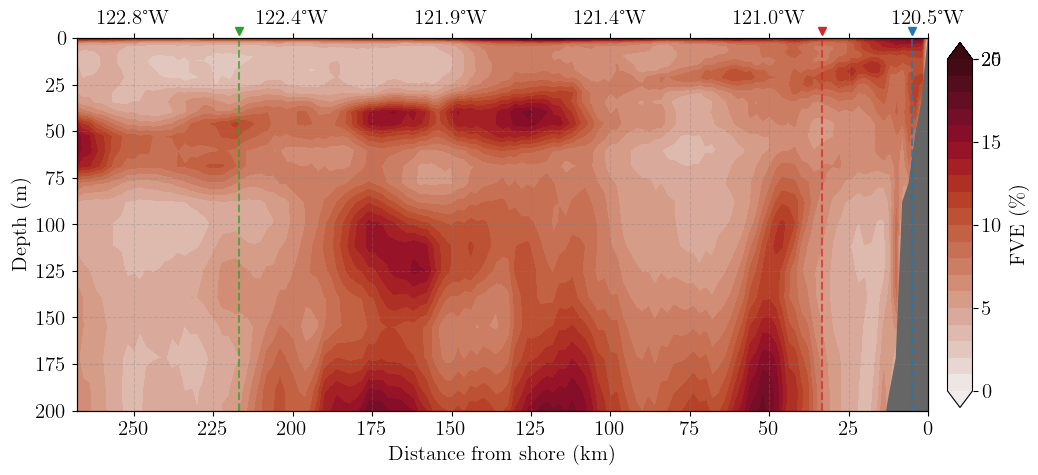

In [43]:
# Set plotting parameter
level = np.arange(0,20+1,1)

# Create figure
fig, ax = plt.subplots(figsize=(10,5))

#--- Subplot 1 ---# 

# Plot decorrelation time scale
cf = ax.contourf(dist,abs(depth),(fve_seg*100).T, levels=level, cmap=cmo.amp, extend='both')

# # Overlay a contourf with hatching for the non-significant regions
# ax.contourf(
#     dist,
#     abs(depth),
#     data_mask.T,
#     levels=[0.5, 1.5],      # anything that spans "1"
#     hatches=['///'],        # your preferred hatching style
#     colors='none',          # keep underlying colormap visible
#     linewidths=0,
#     zorder=10,              # ensure it sits above the shading
# )

# Plot the ocean bottom depth 
ax.fill_between(dist, abs(bottom_depth), abs(depth[-1]), color='0.4') 

# Set axis attributes
ax.set_xlabel('Distance from shore (km)')
ax.set_ylabel('Depth (m)')
ax.set_ylim(0,200)
ax.set_xticks(np.arange(0,250+25,25))
ax.invert_xaxis()
ax.invert_yaxis()
ax.grid(linestyle='--',alpha=0.3,color='grey')

# Set colorbar
cax = fig.add_axes([0.96, 0.16, 0.025, 0.73])# [left, bottom, width, height]
cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both')
cbar.set_label(r'FVE ($\%$)')
cbar.set_ticks(np.arange(0,25+5,5))

# --- Create top axis for longitude --- #
ax_top = ax.twiny()

# Make sure limits match
ax_top.set_xlim(ax.get_xlim())

# Choose where you want longitude ticks (same positions as distance ticks)
dist_ticks = ax.get_xticks()

# Interpolate longitude at those distance values
lon_180 = ((lon + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist, lon_180)

# Create labels but only keep every other one
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set ticks and labels
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels) 

sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist[sort_idx]

# Interpolate longtiude onto distance coordinates 
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

# Add CCE1, CCE2, and CCE3 locations 
add_freq_marker(ax_top, dist1, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:green',markeredgecolor='tab:green')
add_freq_marker(ax_top, dist2, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:red',markeredgecolor='tab:red')
add_freq_marker(ax_top, dist3, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:blue',markeredgecolor='tab:blue')

# Plot vertical lines at CCE1, CCE2, and CCE3 locations
ax.axvline(dist1, color='tab:green', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist2, color='tab:red', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist3, color='tab:blue', linestyle='--', lw=1.5, alpha=0.7)

# Display 
plt.tight_layout()
plt.show()

# Save with high quality
# figName = 'fig09.png'

# fig.savefig(
#     PATH_figs + figName,
#     dpi=300,
#     facecolor='white',
#     bbox_inches='tight',
#     pad_inches=0.1,
#     transparent=False
# )


Compute the FVE from the mean spectrum

In [12]:
# Create frequency mask for high and low frequency bands
mask_low  = f_cpd_seg <= f_cut
mask_high = ~mask_low

# Compute frequency spacing (IMPORTANT)
df = np.gradient(f_cpd_seg)

# Apply masks and integrate over frequency axis
var_high_m = np.sum(S_seg * mask_high * df, axis=2)
var_low_m  = np.sum(S_seg * mask_low  * df, axis=2)

# Compute the fraction of variance explained by the high-frequency variability
fve_seg_mean = var_high_m/var_anomaly 


/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_67806/3254222708.py:13: RuntimeWarning: invalid value encountered in divide
  fve_seg_mean = var_high_m/var_anomaly


/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_67806/205888369.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


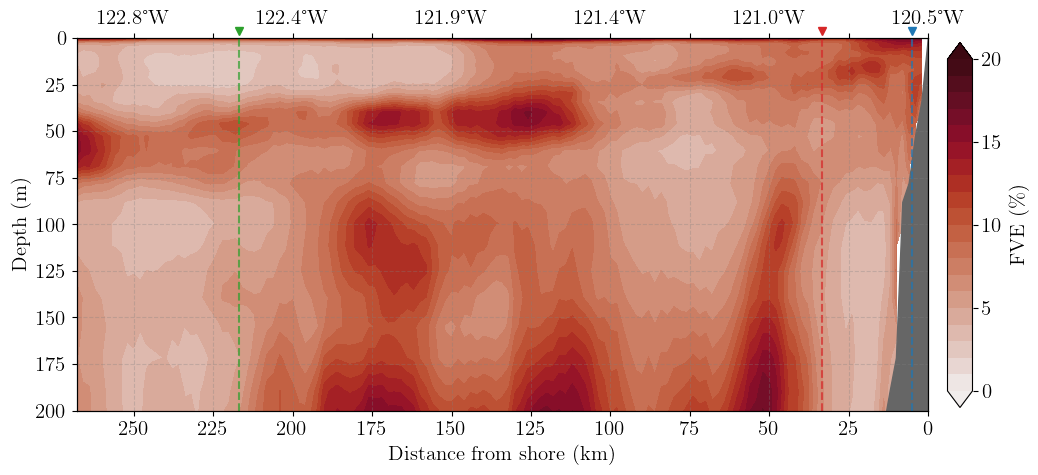

In [13]:
# Set plotting parameter
level = np.arange(0,20+1,1)

# Create figure
fig, ax = plt.subplots(figsize=(10,5))

#--- Subplot 1 ---# 

# Plot decorrelation time scale
cf = ax.contourf(dist,abs(depth),(fve_seg_mean*100).T, levels=level, cmap=cmo.amp, extend='both')

# # Overlay a contourf with hatching for the non-significant regions
# ax.contourf(
#     dist,
#     abs(depth),
#     data_mask.T,
#     levels=[0.5, 1.5],      # anything that spans "1"
#     hatches=['///'],        # your preferred hatching style
#     colors='none',          # keep underlying colormap visible
#     linewidths=0,
#     zorder=10,              # ensure it sits above the shading
# )

# Plot the ocean bottom depth 
ax.fill_between(dist, abs(bottom_depth), abs(depth[-1]), color='0.4') 

# Set axis attributes
ax.set_xlabel('Distance from shore (km)')
ax.set_ylabel('Depth (m)')
ax.set_ylim(0,200)
ax.set_xticks(np.arange(0,250+25,25))
ax.invert_xaxis()
ax.invert_yaxis()
ax.grid(linestyle='--',alpha=0.3,color='grey')

# Set colorbar
cax = fig.add_axes([0.96, 0.16, 0.025, 0.73])# [left, bottom, width, height]
cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both')
cbar.set_label(r'FVE ($\%$)')
cbar.set_ticks(np.arange(0,20+5,5))

# --- Create top axis for longitude --- #
ax_top = ax.twiny()

# Make sure limits match
ax_top.set_xlim(ax.get_xlim())

# Choose where you want longitude ticks (same positions as distance ticks)
dist_ticks = ax.get_xticks()

# Interpolate longitude at those distance values
lon_180 = ((lon + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist, lon_180)

# Create labels but only keep every other one
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set ticks and labels
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels) 

sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist[sort_idx]

# Interpolate longtiude onto distance coordinates 
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

# Add CCE1, CCE2, and CCE3 locations 
add_freq_marker(ax_top, dist1, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:green',markeredgecolor='tab:green')
add_freq_marker(ax_top, dist2, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:red',markeredgecolor='tab:red')
add_freq_marker(ax_top, dist3, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:blue',markeredgecolor='tab:blue')

# Plot vertical lines at CCE1, CCE2, and CCE3 locations
ax.axvline(dist1, color='tab:green', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist2, color='tab:red', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist3, color='tab:blue', linestyle='--', lw=1.5, alpha=0.7)

# Display 
plt.tight_layout()
plt.show()

# Save with high quality
# figName = 'fig09.png'

# fig.savefig(
#     PATH_figs + figName,
#     dpi=300,
#     facecolor='white',
#     bbox_inches='tight',
#     pad_inches=0.1,
#     transparent=False
# )


Compute the depth averaged spectrum 

In [17]:
# Define a function for computing the depth-averaged spectrum with NaN handling
def depth_avg_spectrum(S, mask, dz):
    """
    NaN-aware depth-averaged spectrum.
    """
    S_sub = S[:, mask, :]              # (nsite, nmask, nfreq)
    weights = dz[mask]                # (nmask,)

    W = weights[None, :, None]        # broadcast to (1, nmask, 1)

    # Mask invalid values
    valid = ~np.isnan(S_sub)

    # Weighted sum (ignore NaNs)
    numerator = np.nansum(S_sub * W, axis=1)

    # Sum of weights ONLY where data exists
    denominator = np.nansum(W * valid, axis=1)

    return numerator / denominator

# Ensure positive depths
depth_abs = np.abs(depth)

# Compute layer thickness
dz = np.gradient(depth_abs)

# Define masks
mask_0_25   = (depth_abs >= 0) & (depth_abs <= 25)
mask_25_75  = (depth_abs > 25) & (depth_abs <= 75)
mask_75_200 = (depth_abs > 75) & (depth_abs <= 200)
mask_0_200   = (depth_abs >= 0) & (depth_abs <= 200)

# Compute depth-averaged spectra
S_full   = depth_avg_spectrum(S_seg, mask_0_200, dz)
S_0_25   = depth_avg_spectrum(S_seg, mask_0_25, dz)
S_25_75  = depth_avg_spectrum(S_seg, mask_25_75, dz)
S_75_200 = depth_avg_spectrum(S_seg, mask_75_200, dz)

Plot the depth average spectrum as a function of distance from shore

/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_67806/3173360309.py:13: UserWarning: Log scale: values of z <= 0 have been masked
  cf = ax.contourf(dist,f_cpd_seg, S_full.T, levels=levels, cmap=cmo.deep_r, extend='both', norm=norm)
/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_67806/3173360309.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


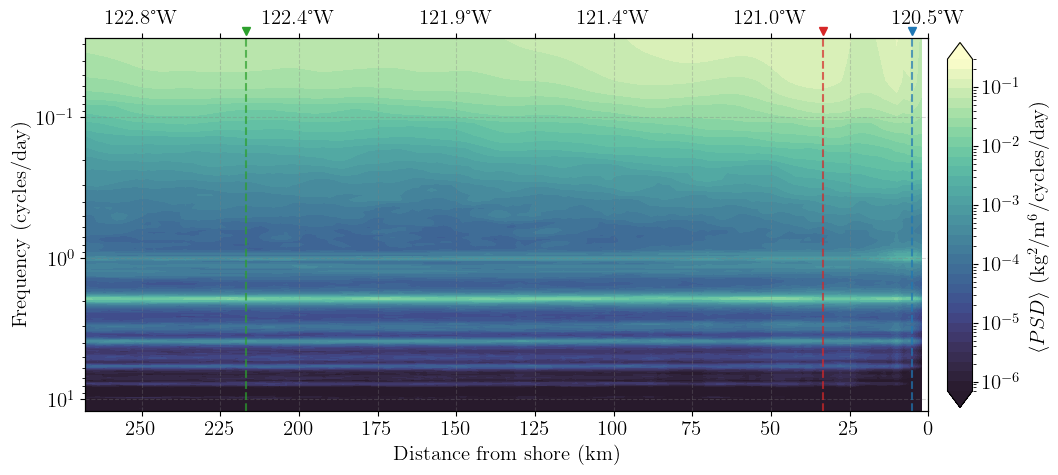

In [23]:
# Set plotting parameter
levels = np.logspace(np.log10(7e-7), np.log10(3e-1), num=35)

# Define logarithmic normalization
norm = mcolors.LogNorm(vmin=7e-7, vmax=3e-1)

# Create figure
fig, ax = plt.subplots(figsize=(10,5))

#--- Subplot 1 ---# 

# Plot decorrelation time scale
cf = ax.contourf(dist,f_cpd_seg, S_full.T, levels=levels, cmap=cmo.deep_r, extend='both', norm=norm)

# Set axis attributes
ax.set_xlabel('Distance from shore (km)')
ax.set_ylabel('Frequency (cycles/day)')
ax.set_ylim(f_cpd_seg[1],f_cpd_seg[-1])
ax.set_yscale('log')
ax.set_xticks(np.arange(0,250+25,25))
ax.invert_xaxis()
ax.invert_yaxis()
ax.grid(linestyle='--',alpha=0.3,color='grey')

# Set colorbar
cax = fig.add_axes([0.96, 0.16, 0.025, 0.73])# [left, bottom, width, height]
cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both')
cbar.ax.yaxis.set_major_locator(mticker.LogLocator(base=10))
cbar.ax.yaxis.set_minor_locator(mticker.LogLocator(base=10, subs=np.arange(2, 10)*0.1))
cbar.ax.yaxis.set_major_formatter(mticker.LogFormatterMathtext())
cbar.ax.yaxis.set_minor_formatter(mticker.NullFormatter())
cbar.set_label(r'$\langle PSD \rangle$ (kg$^2$/m$^6$/cycles/day)')

# --- Create top axis for longitude --- #
ax_top = ax.twiny()

# Make sure limits match
ax_top.set_xlim(ax.get_xlim())

# Choose where you want longitude ticks (same positions as distance ticks)
dist_ticks = ax.get_xticks()

# Interpolate longitude at those distance values
lon_180 = ((lon + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist, lon_180)

# Create labels but only keep every other one
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set ticks and labels
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels) 

sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist[sort_idx]

# Interpolate longtiude onto distance coordinates 
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

# Add CCE1, CCE2, and CCE3 locations 
add_freq_marker(ax_top, dist1, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:green',markeredgecolor='tab:green')
add_freq_marker(ax_top, dist2, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:red',markeredgecolor='tab:red')
add_freq_marker(ax_top, dist3, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:blue',markeredgecolor='tab:blue')

# Plot vertical lines at CCE1, CCE2, and CCE3 locations
ax.axvline(dist1, color='tab:green', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist2, color='tab:red', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist3, color='tab:blue', linestyle='--', lw=1.5, alpha=0.7)

# Display 
plt.tight_layout()
plt.show()

# Save with high quality
# figName = 'fig09.png'

# fig.savefig(
#     PATH_figs + figName,
#     dpi=300,
#     facecolor='white',
#     bbox_inches='tight',
#     pad_inches=0.1,
#     transparent=False
# )


Plot the depth average spectrograms for each regime in a single figure

/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_67806/3525786615.py:14: UserWarning: Log scale: values of z <= 0 have been masked
  cf = ax.contourf(dist,f_cpd_seg, S_0_25.T, levels=levels, cmap=cmo.deep_r, extend='both', norm=norm)
/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_67806/3525786615.py:72: UserWarning: Log scale: values of z <= 0 have been masked
  ax.contourf(dist,f_cpd_seg, S_25_75.T, levels=levels, cmap=cmo.deep_r, extend='both', norm=norm)
/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_67806/3525786615.py:133: UserWarning: Log scale: values of z <= 0 have been masked
  ax.contourf(dist,f_cpd_seg, S_75_200.T, levels=levels, cmap=cmo.deep_r, extend='both', norm=norm)
/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_67806/3525786615.py:200: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


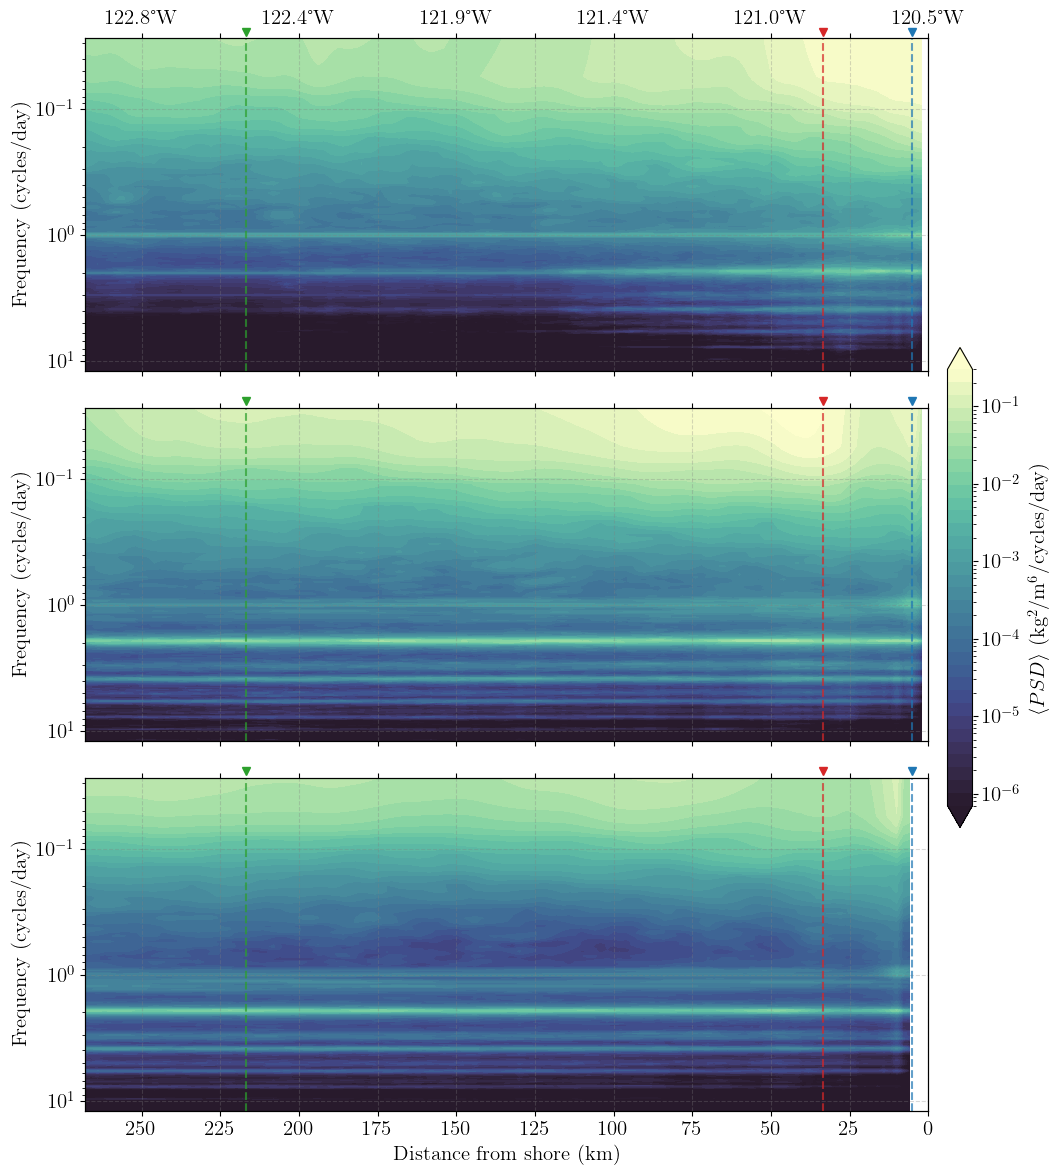

In [39]:
# Set plotting parameter
levels = np.logspace(np.log10(7e-7), np.log10(3e-1), num=35)

# Define logarithmic normalization
norm = mcolors.LogNorm(vmin=7e-7, vmax=3e-1)

# Create figure
fig, axes = plt.subplots(3,1,figsize=(10,12))

#--- Subplot 1 ---# 
ax = axes[0]

# Plot decorrelation time scale
cf = ax.contourf(dist,f_cpd_seg, S_0_25.T, levels=levels, cmap=cmo.deep_r, extend='both', norm=norm)

# Set axis attributes
ax.set_ylabel('Frequency (cycles/day)')
ax.set_ylim(f_cpd_seg[1],f_cpd_seg[-1])
ax.set_yscale('log')
ax.set_xticks(np.arange(0,250+25,25))
ax.invert_xaxis()
ax.invert_yaxis()
ax.grid(linestyle='--',alpha=0.3,color='grey')
ax.set_xticklabels([])

# --- Create top axis for longitude --- #
ax_top = ax.twiny()

# Make sure limits match
ax_top.set_xlim(ax.get_xlim())

# Choose where you want longitude ticks (same positions as distance ticks)
dist_ticks = ax.get_xticks()

# Interpolate longitude at those distance values
lon_180 = ((lon + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist, lon_180)

# Create labels but only keep every other one
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set ticks and labels
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels) 

sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist[sort_idx]

# Interpolate longtiude onto distance coordinates 
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

# Add CCE1, CCE2, and CCE3 locations 
add_freq_marker(ax_top, dist1, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:green',markeredgecolor='tab:green')
add_freq_marker(ax_top, dist2, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:red',markeredgecolor='tab:red')
add_freq_marker(ax_top, dist3, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:blue',markeredgecolor='tab:blue')

# Plot vertical lines at CCE1, CCE2, and CCE3 locations
ax.axvline(dist1, color='tab:green', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist2, color='tab:red', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist3, color='tab:blue', linestyle='--', lw=1.5, alpha=0.7)

#--- Subplot 2 ---# 
ax = axes[1]

# Plot decorrelation time scale
ax.contourf(dist,f_cpd_seg, S_25_75.T, levels=levels, cmap=cmo.deep_r, extend='both', norm=norm)

# Set axis attributes
ax.set_ylabel('Frequency (cycles/day)')
ax.set_ylim(f_cpd_seg[1],f_cpd_seg[-1])
ax.set_yscale('log')
ax.set_xticks(np.arange(0,250+25,25))
ax.invert_xaxis()
ax.invert_yaxis()
ax.grid(linestyle='--',alpha=0.3,color='grey')
ax.set_xticklabels([])

# --- Create top axis for longitude --- #
ax_top = ax.twiny()

# Make sure limits match
ax_top.set_xlim(ax.get_xlim())

# Choose where you want longitude ticks (same positions as distance ticks)
dist_ticks = ax.get_xticks()

# Interpolate longitude at those distance values
lon_180 = ((lon + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist, lon_180)

# Create labels but only keep every other one
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set ticks and labels
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels) 

sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist[sort_idx]

# Interpolate longtiude onto distance coordinates 
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

# Add CCE1, CCE2, and CCE3 locations 
add_freq_marker(ax_top, dist1, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:green',markeredgecolor='tab:green')
add_freq_marker(ax_top, dist2, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:red',markeredgecolor='tab:red')
add_freq_marker(ax_top, dist3, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:blue',markeredgecolor='tab:blue')

# Plot vertical lines at CCE1, CCE2, and CCE3 locations
ax.axvline(dist1, color='tab:green', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist2, color='tab:red', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist3, color='tab:blue', linestyle='--', lw=1.5, alpha=0.7)

# Remove top x labels
ax_top.set_xticklabels([])

#--- Subplot 3 ---# 
ax = axes[2]

# Plot decorrelation time scale
ax.contourf(dist,f_cpd_seg, S_75_200.T, levels=levels, cmap=cmo.deep_r, extend='both', norm=norm)

# Set axis attributes
ax.set_xlabel('Distance from shore (km)')
ax.set_ylabel('Frequency (cycles/day)')
ax.set_ylim(f_cpd_seg[1],f_cpd_seg[-1])
ax.set_yscale('log')
ax.set_xticks(np.arange(0,250+25,25))
ax.invert_xaxis()
ax.invert_yaxis()
ax.grid(linestyle='--',alpha=0.3,color='grey')

# --- Create top axis for longitude --- #
ax_top = ax.twiny()

# Make sure limits match
ax_top.set_xlim(ax.get_xlim())

# Choose where you want longitude ticks (same positions as distance ticks)
dist_ticks = ax.get_xticks()

# Interpolate longitude at those distance values
lon_180 = ((lon + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist, lon_180)

# Create labels but only keep every other one
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set ticks and labels
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels) 

sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist[sort_idx]

# Interpolate longtiude onto distance coordinates 
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

# Add CCE1, CCE2, and CCE3 locations 
add_freq_marker(ax_top, dist1, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:green',markeredgecolor='tab:green')
add_freq_marker(ax_top, dist2, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:red',markeredgecolor='tab:red')
add_freq_marker(ax_top, dist3, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:blue',markeredgecolor='tab:blue')

# Plot vertical lines at CCE1, CCE2, and CCE3 locations
ax.axvline(dist1, color='tab:green', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist2, color='tab:red', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist3, color='tab:blue', linestyle='--', lw=1.5, alpha=0.7)

# Remove top x labels
ax_top.set_xticklabels([])

# Set colorbar
cax = fig.add_axes([0.96, 0.3, 0.025, 0.4])# [left, bottom, width, height]
cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both')
cbar.ax.yaxis.set_major_locator(mticker.LogLocator(base=10))
cbar.ax.yaxis.set_minor_locator(mticker.LogLocator(base=10, subs=np.arange(2, 10)*0.1))
cbar.ax.yaxis.set_major_formatter(mticker.LogFormatterMathtext())
cbar.ax.yaxis.set_minor_formatter(mticker.NullFormatter())
cbar.set_label(r'$\langle PSD \rangle$ (kg$^2$/m$^6$/cycles/day)')

# Display 
plt.tight_layout()
plt.show()

# Save with high quality
# figName = 'fig09.png'

# fig.savefig(
#     PATH_figs + figName,
#     dpi=300,
#     facecolor='white',
#     bbox_inches='tight',
#     pad_inches=0.1,
#     transparent=False
# )


Save data in a npz file 

In [ ]:
# Check if file exists, then delete it
file_path = PATH + "mitgcm_transect_potential_density_spectra.npz"
if os.path.exists(file_path):
    os.remove(file_path)

# Set metadata
metadata = {
    'description': 'Potential Density depth spectrogram and fraction of variance energy explained by high frequency variability greater than 1 week across the CalCOFI line 80 transect.',
    'source': 'MITgcm model output',
    'coordinates units': '1 hr'
}
    
# Save data arrays and metadata to a .npz file
np.savez(file_path,
    S              = S_seg,
    S_0_200        = S_full,
    S_0_25         = S_0_25,
    S_25_75        = S_25_75,
    S_75_200       = S_75_200,
    CI             = CI_seg,
    FVE            = fve_seg,
    FVE_unc        = fve_seg_unc,
    var_anom       = var_anomaly,
    var_anom_unc   = var_anomaly_unc,
    lon            = lon,
    lat            = lat,
    depth          = depth,
    dist           = dist,
    f_cpd          = f_cpd_seg,
    metadata       = metadata
    )